In [1]:
import requests
import configparser

In [33]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

In [2]:

config_file = configparser.ConfigParser()
config_file.read("config.ini")

username = config_file["copernicus"]["username"]
password = config_file["copernicus"]["password"]

In [25]:
def get_access_token(username: str, password: str) -> str:
    # Prepare the data for the token request
    data = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    
    # Send the request to get the access token
    try:
        r = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
            data=data,
        )
        r.raise_for_status()
        access_token = r.json().get("access_token")
        if not access_token:
            raise ValueError("No access token found in response.")
        return access_token
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None

# Retrieve the token
access_token = get_access_token(username, password)

In [39]:



url = "https://sh.dataspace.copernicus.eu/api/v1/process"

headers={
  "Content-Type": "application/json",
  "Authorization" : "Bearer "+ access_token
}

json={
    "input": {
        "bounds": {
            "bbox": [-0.889549, 37.621846, -0.681152, 37.828226]
        },
        "data": [
            {
            "dataFilter": {
                "timeRange": {
                  "from": "2024-10-12T00:00:00Z",
                  "to": "2024-11-12T23:59:59Z"
                }
            },
            "type": "sentinel-2-l2a"
            }]
    },
    "output": {
        "responses": [
            {
                "identifier": "default",
                "format": {
                    "type": "image/png"
                }
            }
        ]
    },
    "evalscript" :
    """
        //VERSION=3

        function setup() {
            return {
                input: [{
                    bands: ["B02", "B03", "B04"]
                }],
                output: {
                    bands: 3
                }
            };
        }

        function evaluatePixel(sample) {
            return [sample.B04, sample.B03, sample.B02];
        }
     """
}

#   function setup() {
#     return {
#       input: ["B02", "B03", "B04"],
#       output: {
#         bands: 3
#       }
#     };
#   }

#   function evaluatePixel(
#     sample,
#     scenes,
#     inputMetadata,
#     customData,
#     outputMetadata
#   ) {
#     return [2.5 * sample.B04, 2.5 * sample.B03, 2.5 * sample.B02];
#   }

# })


In [40]:
response = requests.post(url, headers=headers, json=json)

In [41]:
response.content

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\x00\x00\x00\x01\x00\x08\x02\x00\x00\x00\xd3\x10?1\x00\x00\x80\x00IDATx^\x8c\xbc\xf9\x97$\xd7y%\xd6fwU\xe5\x1a\xfb\xbe\xef{FF\xee{\xe5R{UwUW\xef\xfb\x86F\xa3W4\xc0\x06\xb1\xef\x04\xb1\x11 \x00\x82\x04\t\x8a\x12%.25#J\x94F\xe6\x8c\xa5\x91\xe8\xb1,\x8d\x8f\xce\xc8\xd2h<>\x9a\x19\x1f\xff`\x8f\xe7\x0f\xf0_\xe0/2\xab\x1b\r\x90s\xec:\xef\xc4\xc9\x8c\x8a\x8cx\x11q\xef\xf7\xdd\xfb\xbd\x17\xb1O\xe10G&cWPD\\\x140\x81G\x1d\x83\xd3E\x82\xa7\x11\x8eF\r\x89v\x0c\xbe^\xf6\xca\x9e\xd1*Y\xae!X\n\xdb\xae\xf8\xab\rw\x94\x98]_\x88\r.\xf14Gf\xaa\xae<lU\xb7\x86\xadSK\xd5\xedamwsyw}rl\\9\xd4\xb4\x1b\xaeh\x8aDd\xb2%G\x1ew\x1b\xa3NM\x97HE\xa0\x1a\x91U\x8b\xec\x95\xc5\xce\xa4\xdf\xee\xb7j\xcdj\xa0k\x02\x8a\xe6\t\xbc\xc02X\xab\x12\xb4*a\xa7\x9e\x9c<|hwk\xa3Qr:\xa1\xdc\x0b\x95\x02\x92\xe3Y\x82\xc0\x8b\x96\xc28\n#r8\xc5\xa0Y,Kq\xe8 1/\xad\xd5N\x0c\xe3V\xa8\xd9*;,\x9b5O\xa9$I\x14\x86\x9ec/5\x82\xf5\x8ew\xeb\xe6\xad+\xe7On\xad,\x0e{\xedN\xd9\xa3xLQ\x08[\xa5\x19\x06gY\

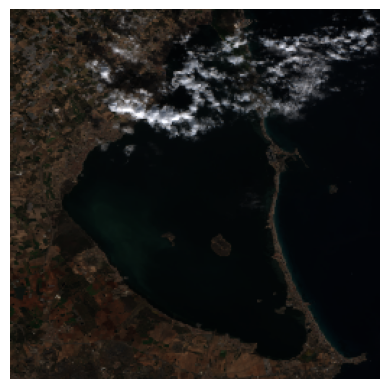

In [42]:
image = Image.open(BytesIO(response.content))

# Plot the image
plt.imshow(image)
plt.axis('off')  # Hide axes for better visualization
plt.show()